# Model Comparison — All Checkpoints

Evaluates every trained checkpoint and produces CER / WER comparison tables.

| Group | Checkpoint | Training path |
|---|---|---|
| Bentham | `best/` | base → Bentham R0 |
| Bentham Aug | `best_aug/` | base → Bentham R0 (augmented) |
| READ (Bentham init) | `best_read/` | best → READ |
| READ (base init) | `best_read_base/` | base → READ |
| READ Stage 1 only | `stage1_read/` | base → READ (encoder frozen) |
| READ 2-Stage | `best_read_2stage/` | base → READ (progressive unfreezing) |

## Step 1 — Imports & Setup

In [1]:
import torch
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from tqdm.notebook import tqdm

PAGE_NS           = "http://schema.primaresearch.org/PAGE/gts/pagecontent/2013-07-15"
KEEP_REGION_TYPES = {"paragraph", "heading"}
READ_DIR          = Path("../data/READDataset")
CKPT_ROOT         = Path("../checkpoints")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Checkpoints root : {CKPT_ROOT.resolve()}")

Device : cuda
Checkpoints root : /home/justin/Ginger_Gradient/14/project/Capstone-Project/checkpoints


## Step 2 — Load READ Test Set

In [2]:
def _parse_page_xml(xml_path, image_path):
    ns, records = {"p": PAGE_NS}, []
    for region in ET.parse(xml_path).getroot().findall(".//p:TextRegion", ns):
        rtype = region.get("type")
        if rtype is not None and rtype not in KEEP_REGION_TYPES:
            continue
        for line in region.findall(".//p:TextLine", ns):
            u      = line.find(".//p:Unicode", ns)
            coords = line.find("p:Coords", ns)
            if u is None or not (u.text or "").strip() or coords is None:
                continue
            pts  = coords.get("points", "")
            xs   = [int(p.split(",")[0]) for p in pts.split()]
            ys   = [int(p.split(",")[1]) for p in pts.split()]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            if bbox[2] > bbox[0] and bbox[3] > bbox[1]:
                records.append({"image_path": str(image_path), "bbox": bbox,
                                 "transcription": u.text.strip()})
    return records

test_xml_dir = READ_DIR / "Test-ICFHR-2016" / "page"
test_img_dir = READ_DIR / "Test-ICFHR-2016"
records = []
for xml_file in sorted(test_xml_dir.glob("*.xml")):
    img_file = test_img_dir / (xml_file.stem + ".JPG")
    if img_file.exists():
        records.extend(_parse_page_xml(xml_file, img_file))

import pandas as _pd
df_read_test = _pd.DataFrame(records)
print(f"READ test lines : {len(df_read_test)}")

READ test lines : 1138


## Step 3 — Evaluation Helper

In [3]:
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

class _Dataset(Dataset):
    def __init__(self, df, processor, max_len=128):
        self.df, self.processor, self.max_len = df, processor, max_len
        self._cache = {}
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if row["image_path"] not in self._cache:
            self._cache[row["image_path"]] = Image.open(row["image_path"]).convert("RGB")
        img          = self._cache[row["image_path"]].crop(row["bbox"])
        pixel_values = self.processor(images=img, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(
            row["transcription"], padding="max_length", max_length=self.max_len,
            truncation=True, return_tensors="pt",
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels}


def evaluate_checkpoint(ckpt_dir, df, label=""):
    """Load checkpoint, run inference on df, return CER/WER dict. Returns None if ckpt missing."""
    ckpt_path = Path(ckpt_dir)
    if not ckpt_path.exists():
        print(f"  ✗ MISSING: {ckpt_path}")
        return None
    processor = TrOCRProcessor.from_pretrained(ckpt_path)
    model     = VisionEncoderDecoderModel.from_pretrained(ckpt_path).to(device)
    model.eval()
    loader = DataLoader(_Dataset(df, processor), batch_size=16, shuffle=False, num_workers=0)
    all_preds, all_refs = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"  {label}", leave=False):
            pixel_values  = batch["pixel_values"].to(device)
            labels        = batch["labels"].clone()
            generated_ids = model.generate(pixel_values, max_new_tokens=128)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs  = processor.batch_decode(labels, skip_special_tokens=True)
            all_preds.extend(preds)
            all_refs.extend(refs)
    cer = cer_metric.compute(predictions=all_preds, references=all_refs)
    wer = wer_metric.compute(predictions=all_preds, references=all_refs)
    del model
    torch.cuda.empty_cache()
    return {"CER (%)": round(cer * 100, 2), "WER (%)": round(wer * 100, 2)}

print("Eval helper ready.")

Eval helper ready.


## Step 4 — Evaluate READ Models

In [4]:
READ_MODELS = [
    ("best_read",        "Bentham → READ"),
    ("best_read_base",   "Base → READ (direkt)"),
    ("stage1_read",      "Base → READ (Stage 1, Encoder frozen)"),
    ("best_read_2stage", "Base → READ (2-Stage progressive)"),
]

read_rows = []
for ckpt_name, label in READ_MODELS:
    print(f"Evaluating: {label}")
    result = evaluate_checkpoint(CKPT_ROOT / ckpt_name, df_read_test, label)
    if result:
        read_rows.append({"Modell": label, "Checkpoint": ckpt_name, **result})

df_read_results = pd.DataFrame(read_rows).set_index("Modell")
print("\n" + "="*55)
print("READ Test Set — CER / WER")
print("="*55)
display(df_read_results)

Evaluating: Bentham → READ


  Bentham → READ:   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating: Base → READ (direkt)


  Base → READ (direkt):   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating: Base → READ (Stage 1, Encoder frozen)


  Base → READ (Stage 1, Encoder frozen):   0%|          | 0/72 [00:00<?, ?it/s]

Evaluating: Base → READ (2-Stage progressive)


  Base → READ (2-Stage progressive):   0%|          | 0/72 [00:00<?, ?it/s]


READ Test Set — CER / WER


,Checkpoint,CER (%),WER (%)
Modell,,,
Bentham → READ,best_read,7.36,30.56
Base → READ (direkt),best_read_base,6.18,27.24
"Base → READ (Stage 1, Encoder frozen)",stage1_read,22.39,52.13
Base → READ (2-Stage progressive),best_read_2stage,15.97,42.99


## Step 5 — Known Results: Bentham & Washington Cross-Eval

Results from previous runs (hardcoded — re-run `inkference_ar.ipynb` and `cross_eval_washington.ipynb` to refresh).

In [5]:
df_bentham = pd.DataFrame([
    {
        "Modell":                "Base → Bentham",
        "Checkpoint":            "best/",
        "Bentham Test CER (%)":  3.90,
        "Bentham Test WER (%)":  "—",
        "Washington CER (%)":    14.49,
        "Washington WER (%)":    "—",
    },
    {
        "Modell":                "Base → Bentham (Aug)",
        "Checkpoint":            "best_aug/",
        "Bentham Test CER (%)":  4.51,
        "Bentham Test WER (%)":  "—",
        "Washington CER (%)":    16.04,
        "Washington WER (%)":    37.11,
    },
]).set_index("Modell")

print("="*65)
print("Bentham + Washington Cross-Evaluation")
print("="*65)
display(df_bentham)

Bentham + Washington Cross-Evaluation


,Checkpoint,Bentham Test CER (%),Bentham Test WER (%),Washington CER (%),Washington WER (%)
Modell,,,,,
Base → Bentham,best/,3.90,—,14.49,—
Base → Bentham (Aug),best_aug/,4.51,—,16.04,37.11


## Step 6 — Visualisation

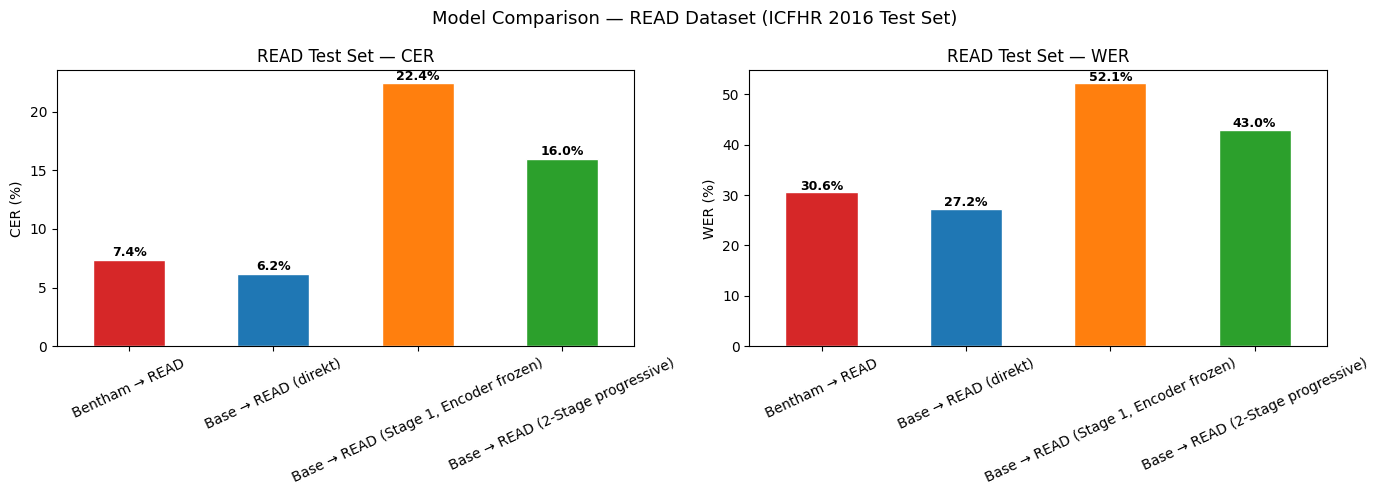

Saved to ../checkpoints/model_comparison_READ.png


In [6]:
colors = ["#d62728", "#1f77b4", "#ff7f0e", "#2ca02c"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CER
df_read_results["CER (%)"].plot(
    kind="bar", ax=axes[0], color=colors[:len(df_read_results)], edgecolor="white"
)
axes[0].set_title("READ Test Set — CER", fontsize=12)
axes[0].set_ylabel("CER (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)
for i, v in enumerate(df_read_results["CER (%)"]):
    axes[0].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

# WER
df_read_results["WER (%)"].plot(
    kind="bar", ax=axes[1], color=colors[:len(df_read_results)], edgecolor="white"
)
axes[1].set_title("READ Test Set — WER", fontsize=12)
axes[1].set_ylabel("WER (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=25)
for i, v in enumerate(df_read_results["WER (%)"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Model Comparison — READ Dataset (ICFHR 2016 Test Set)", fontsize=13)
plt.tight_layout()

out_path = CKPT_ROOT / "model_comparison_READ.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out_path}")

## Step 7 — Summary Table (All Models)

In [7]:
print("\n" + "="*70)
print("COMPLETE MODEL OVERVIEW")
print("="*70)

print("\n--- Bentham domain ---")
display(df_bentham)

print("\n--- READ domain (ICFHR 2016 test set) ---")
display(df_read_results.sort_values("CER (%)"))

best_read_idx = df_read_results["CER (%)"].idxmin()
best_read_cer = df_read_results.loc[best_read_idx, "CER (%)"]
best_read_wer = df_read_results.loc[best_read_idx, "WER (%)"]
print(f"\nBest READ model : {best_read_idx}")
print(f"  CER : {best_read_cer:.2f}%")
print(f"  WER : {best_read_wer:.2f}%")


COMPLETE MODEL OVERVIEW

--- Bentham domain ---


,Checkpoint,Bentham Test CER (%),Bentham Test WER (%),Washington CER (%),Washington WER (%)
Modell,,,,,
Base → Bentham,best/,3.90,—,14.49,—
Base → Bentham (Aug),best_aug/,4.51,—,16.04,37.11



--- READ domain (ICFHR 2016 test set) ---


,Checkpoint,CER (%),WER (%)
Modell,,,
Base → READ (direkt),best_read_base,6.18,27.24
Bentham → READ,best_read,7.36,30.56
Base → READ (2-Stage progressive),best_read_2stage,15.97,42.99
"Base → READ (Stage 1, Encoder frozen)",stage1_read,22.39,52.13



Best READ model : Base → READ (direkt)
  CER : 6.18%
  WER : 27.24%
